# Training Comparison Results

Generates graphs showing the training and validation losses (both safe and unsafe) over the indicated duration.

Unfortunately, given the specification of timestamps, it will be necessary to select the filenames individually when loading into the dictionary. Once done, then the `batch_num` property will have to be manually adjusted based on how many batches you wish to present. Then you will need to index each set accordingly in the dictionary noting that each loaded file ended after the batch number specified in its filename so it has `batch+1` data points.

> Note that if you terminate training of all 3 scripts after the 50 epochs backup data has been generated then you do not need to make any adjustments to the indexing.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
euclid_dir = Path("geo_results/euclid")
flat_dir = Path("geo_results/flat_metric")
nonflat_dir = Path("geo_results/nonflat_metric")

# at 50 iterations results seemed to have converged for the manifold training
euclid_training_results = {
    "safe_train_loss": np.load(euclid_dir.joinpath("bkup_50_safe_train_loss_hist_2026_02_27__11_20.npy")),
    "unsafe_train_loss": np.load(euclid_dir.joinpath("bkup_50_unsafe_train_loss_hist_2026_02_27__11_20.npy")),
    "safe_valid_loss": np.load(euclid_dir.joinpath("bkup_50_safe_valid_loss_hist_2026_02_27__11_20.npy")),
    "unsafe_valid_loss": np.load(euclid_dir.joinpath("bkup_50_unsafe_valid_loss_hist_2026_02_27__11_20.npy"))
}
flat_metric_training_results = {
    "safe_train_loss": np.load(flat_dir.joinpath("bkup_50_safe_train_loss_hist_2026_02_27__10_53.npy")),
    "unsafe_train_loss": np.load(flat_dir.joinpath("bkup_50_unsafe_train_loss_hist_2026_02_27__10_53.npy")),
    "safe_valid_loss": np.load(flat_dir.joinpath("bkup_50_safe_valid_loss_hist_2026_02_27__10_53.npy")),
    "unsafe_valid_loss": np.load(flat_dir.joinpath("bkup_50_unsafe_valid_loss_hist_2026_02_27__10_53.npy")),
}
nonflat_metric_training_results = {
    "safe_train_loss": np.load(nonflat_dir.joinpath("bkup_50_safe_train_loss_hist_2026_02_27__17_16.npy")),
    "unsafe_train_loss": np.load(nonflat_dir.joinpath("bkup_50_unsafe_train_loss_hist_2026_02_27__17_16.npy")),
    "safe_valid_loss": np.load(nonflat_dir.joinpath("bkup_50_safe_valid_loss_hist_2026_02_27__17_16.npy")),
    "unsafe_valid_loss": np.load(nonflat_dir.joinpath("bkup_50_unsafe_valid_loss_hist_2026_02_27__17_16.npy")),
}

In [ ]:
# color selection
euclid_safe_color = "royalblue"
euclid_unsafe_color = "skyblue"

flat_safe_color = "forestgreen"
flat_unsafe_color = "limegreen"

nonflat_safe_color = "crimson"
nonflat_unsafe_color = "tomato"

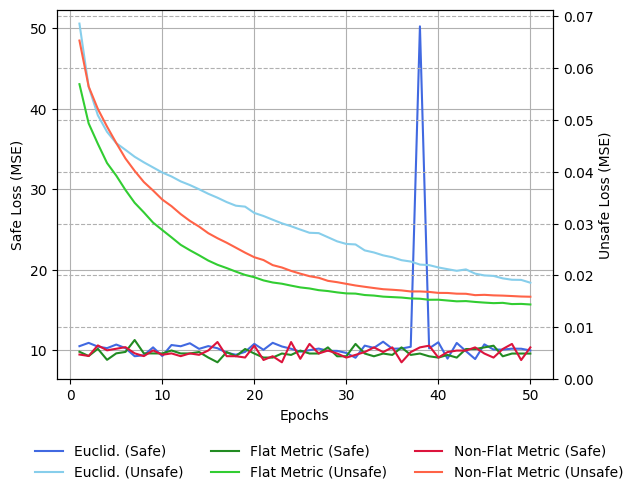

In [ ]:
# training results

fig, ax = plt.subplots(1, 1)
ax2 = ax.twinx()

batch_num = np.arange(1, 50+1) # generates labels for after epoch 1 to after epoch num

# NOTE: manual indexing is required if choosing to take a subset of the total loaded data
euclid_safe, = ax.plot(batch_num, euclid_training_results["safe_train_loss"][:-1], euclid_safe_color, label="Euclid. (Safe)")
euclid_unsafe, = ax2.plot(batch_num, euclid_training_results["unsafe_train_loss"][:-1], euclid_unsafe_color, label="Euclid. (Unsafe)")

flat_safe, = ax.plot(batch_num, flat_metric_training_results["safe_train_loss"][:-1], flat_safe_color, label="Flat Metric (Safe)")
flat_unsafe, = ax2.plot(batch_num, flat_metric_training_results["unsafe_train_loss"][:-1], flat_unsafe_color, label="Flat Metric (Unsafe)")

nonflat_safe, = ax.plot(batch_num, nonflat_metric_training_results["safe_train_loss"][:-1], nonflat_safe_color, label="Non-Flat Metric (Safe)")
nonflat_unsafe, = ax2.plot(batch_num, nonflat_metric_training_results["unsafe_train_loss"][:-1], nonflat_unsafe_color, label="Non-Flat Metric (Unsafe)")

# ax2.spines["right"].set_position(("outward", 60))
ax2.set_ylim(0.0)
ax.set_xlabel("Epochs")
ax.set_ylabel("Safe Loss (MSE)")
ax2.set_ylabel("Unsafe Loss (MSE)")

ax.grid(linestyle="-")
ax2.grid(linestyle="--")

fig.legend(
    handles=[euclid_safe, euclid_unsafe, flat_safe, flat_unsafe, nonflat_safe, nonflat_unsafe], 
    loc="lower center", 
    ncols=3, 
    frameon=False, 
    bbox_to_anchor=(0.55, -0.125)
)
fig.savefig("train_results.png", dpi=300, bbox_inches="tight", pad_inches=0.1)

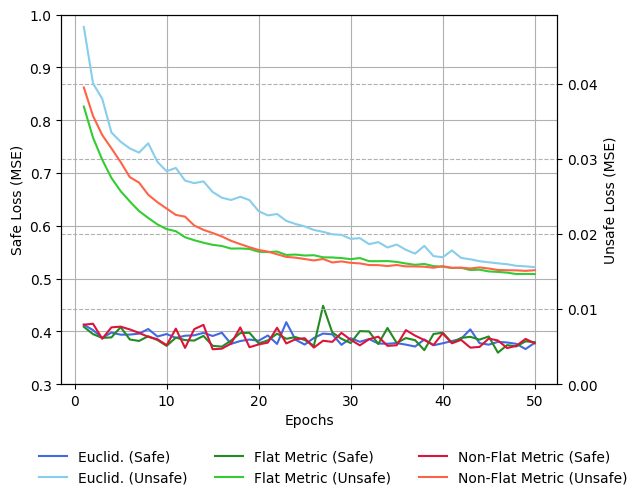

In [ ]:
# validation results

fig, ax = plt.subplots(1, 1)
ax2 = ax.twinx()

batch_num = np.arange(1, 50+1)

euclid_safe, = ax.plot(batch_num, euclid_training_results["safe_valid_loss"][:-1], euclid_safe_color, label="Euclid. (Safe)")
euclid_unsafe, = ax2.plot(batch_num, euclid_training_results["unsafe_valid_loss"][:-1], euclid_unsafe_color, label="Euclid. (Unsafe)")

flat_safe, = ax.plot(batch_num, flat_metric_training_results["safe_valid_loss"][:-1], flat_safe_color, label="Flat Metric (Safe)")
flat_unsafe, = ax2.plot(batch_num, flat_metric_training_results["unsafe_valid_loss"][:-1], flat_unsafe_color, label="Flat Metric (Unsafe)")

nonflat_safe, = ax.plot(batch_num, nonflat_metric_training_results["safe_valid_loss"][:-1], nonflat_safe_color, label="Non-Flat Metric (Safe)")
nonflat_unsafe, = ax2.plot(batch_num, nonflat_metric_training_results["unsafe_valid_loss"][:-1], nonflat_unsafe_color, label="Non-Flat Metric (Unsafe)")

ax.set_ylim(0.3, 1.0)

# ax2.spines["right"].set_position(("outward", 60))
ax2.set_ylim(0.0)
ax.set_xlabel("Epochs")
ax.set_ylabel("Safe Loss (MSE)")
ax2.set_ylabel("Unsafe Loss (MSE)")

ax.grid(linestyle="-")
ax2.grid(linestyle="--")

fig.legend(
    handles=[euclid_safe, euclid_unsafe, flat_safe, flat_unsafe, nonflat_safe, nonflat_unsafe], 
    loc="lower center", 
    ncols=3, 
    frameon=False, 
    bbox_to_anchor=(0.55, -0.125)
)
fig.savefig("validation_results.png", dpi=300, bbox_inches="tight", pad_inches=0.1)